In [ ]:
#CELL 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/MusicGenerationCSE425'
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"Project directory: {PROJECT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/MusicGenerationCSE425


In [ ]:
#CELL 1: Install libraries and mount drive
!pip install pretty_midi -q
from google.colab import drive
drive.mount('/content/drive')
import os, sys

PROJECT_DIR = '/content/drive/MyDrive/MusicGenerationCSE425'
RAW_MIDI_DIR  = f'{PROJECT_DIR}/data/raw_midi'
PROCESSED_DIR = f'{PROJECT_DIR}/data/processed'
os.makedirs(RAW_MIDI_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#CELL 2: Dataset download
import subprocess

MAESTRO_URL = "https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip"
ZIP_PATH = f"{RAW_MIDI_DIR}/maestro-v3.0.0-midi.zip"

if not os.path.exists(ZIP_PATH):
    print("Downloading MAESTRO dataset (~57MB)...")
    !wget -q --show-progress -O {ZIP_PATH} {MAESTRO_URL}
    print("Download complete!")
else:
    print("Already downloaded, skipping.")

# Unzip
MAESTRO_DIR = f"{RAW_MIDI_DIR}/maestro-v3.0.0"
if not os.path.exists(MAESTRO_DIR):
    print("Extracting...")
    !unzip -q {ZIP_PATH} -d {RAW_MIDI_DIR}
    print("Extraction complete!")
else:
    print("Already extracted.")
print(f"\nMAESTRO directory: {MAESTRO_DIR}")

Already downloaded, skipping.
Already extracted.

MAESTRO directory: /content/drive/MyDrive/MusicGenerationCSE425/data/raw_midi/maestro-v3.0.0


In [ ]:
#CELL 3: Loading and inspection of the metadata using pandas
import pandas as pd

CSV_PATH = f"{MAESTRO_DIR}/maestro-v3.0.0.csv"
df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nSplit distribution:")
print(df['split'].value_counts())
print("\nFirst 3 rows:")
df.head(3)

Dataset shape: (1276, 7)

Column names: ['canonical_composer', 'canonical_title', 'split', 'year', 'midi_filename', 'audio_filename', 'duration']

Split distribution:
split
train         962
test          177
validation    137
Name: count, dtype: int64

First 3 rows:


,canonical_composer,canonical_title,split,year,midi_filename,audio_filename,duration
0,Alban Berg,Sonata Op. 1,train,2018,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,698.661160
1,Alban Berg,Sonata Op. 1,train,2008,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,759.518471
2,Alban Berg,Sonata Op. 1,train,2017,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,464.649433


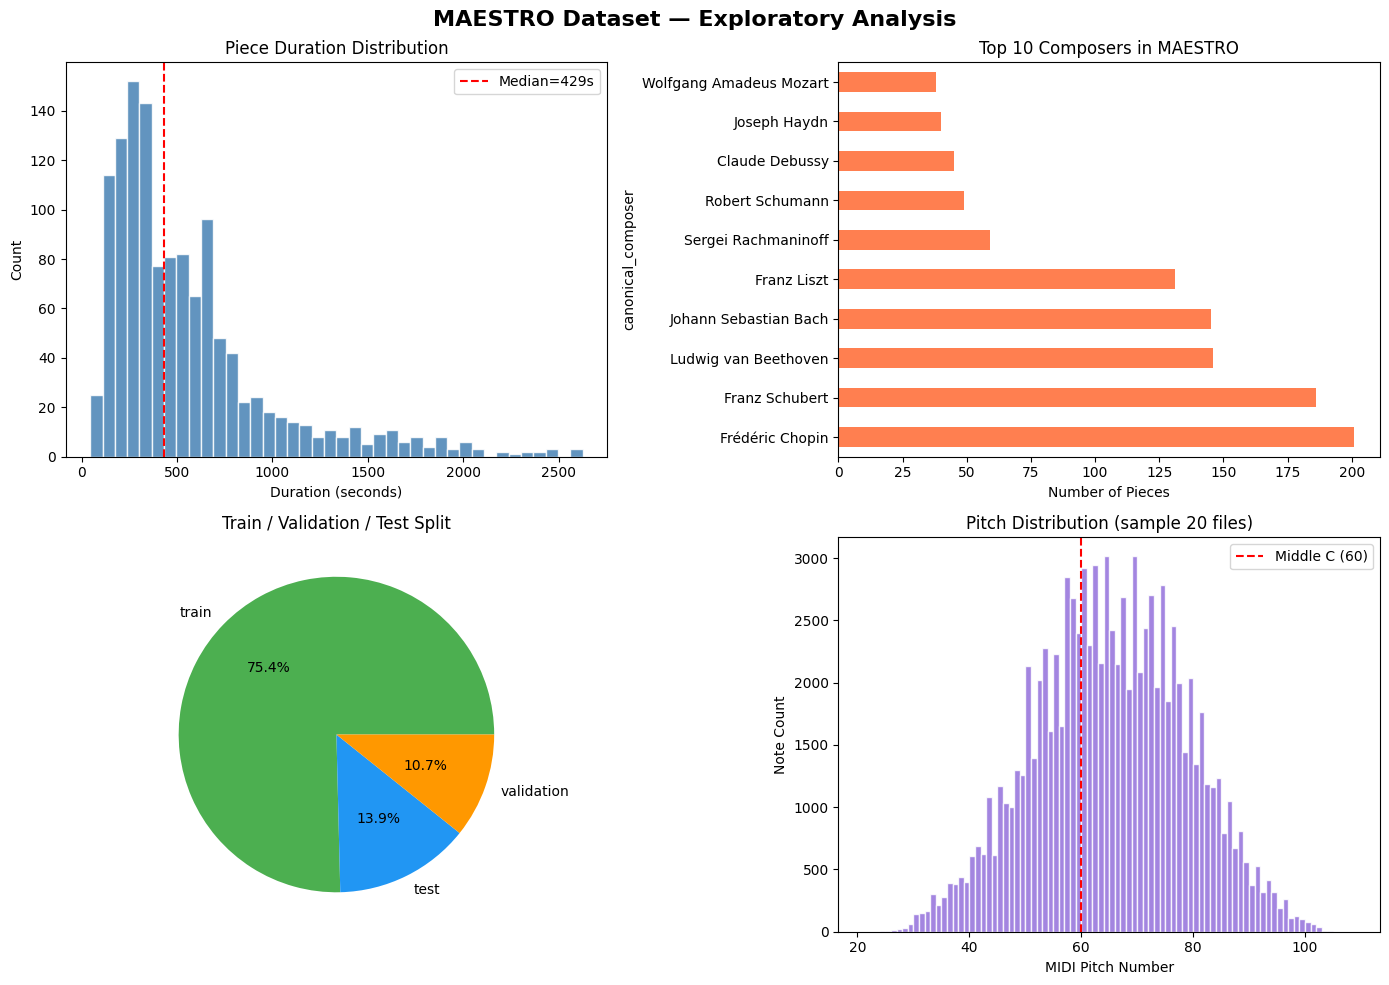

EDA plot saved!


In [ ]:
#CELL 4: EDA
#For producing plots for final report
import matplotlib.pyplot as plt
import pretty_midi
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MAESTRO Dataset — Exploratory Analysis', fontsize=16, fontweight='bold')

#Plot 1: Duration Distribution
ax = axes[0, 0]
durations = df['duration'].values
ax.hist(durations, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Piece Duration Distribution')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Count')
ax.axvline(np.median(durations), color='red', linestyle='--', label=f'Median={np.median(durations):.0f}s')
ax.legend()

#Plot 2: Composer Distribution (top 10)
ax = axes[0, 1]
top_composers = df['canonical_composer'].value_counts().head(10)
top_composers.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 10 Composers in MAESTRO')
ax.set_xlabel('Number of Pieces')

#Plot 3: Split Distribution
ax = axes[1, 0]
split_counts = df['split'].value_counts()
ax.pie(split_counts, labels=split_counts.index, autopct='%1.1f%%',
       colors=['#4CAF50','#2196F3','#FF9800'])
ax.set_title('Train / Validation / Test Split')

#Plot 4: Pitch Distribution (sample of 20 files)
ax = axes[1, 1]
all_pitches = []
sample_files = df[df['split'] == 'train']['midi_filename'].sample(20, random_state=42).tolist()

for fname in sample_files:
    fpath = f"{MAESTRO_DIR}/{fname}"
    try:
        midi = pretty_midi.PrettyMIDI(fpath)
        for inst in midi.instruments:
            for note in inst.notes:
                all_pitches.append(note.pitch)
    except Exception:
        pass  # skip the malformed files

ax.hist(all_pitches, bins=88, range=(21, 109), color='mediumpurple', edgecolor='white', alpha=0.85)
ax.set_title('Pitch Distribution (sample 20 files)')
ax.set_xlabel('MIDI Pitch Number')
ax.set_ylabel('Note Count')
ax.axvline(60, color='red', linestyle='--', label='Middle C (60)')
ax.legend()

plt.tight_layout()
PLOTS_DIR = f"{PROJECT_DIR}/outputs/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)
plt.savefig(f"{PLOTS_DIR}/eda_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("EDA plot saved!")

In [ ]:
#CELL 5: Piano-Roll Preprocessing
#First Converts MIDI to binary piano-roll windows and then to .npy arrays
import pretty_midi
import numpy as np
from tqdm import tqdm

#Hyperparameters
FRAME_RATE = 16
WINDOW_SIZE = 128
MIN_ACTIVITY = 0.02
PIANO_MIN = 21
PIANO_MAX = 108
N_PITCHES = PIANO_MAX - PIANO_MIN + 1

def midi_to_piano_roll_windows(midi_path, frame_rate=FRAME_RATE, window_size=WINDOW_SIZE, min_activity=MIN_ACTIVITY):
    """
    Load a MIDI file and convert it to a list of binary piano-roll windows.
    Args: midi_path: path to .midi file, frame_rate: fps for piano-roll, window_size : number of frames in each training window , min_activity: minimum fraction of active cells to keep a window
    What it returns: is a list of numpy arrays, each of shape (window_size, 88)
    """
    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
    except Exception as e:
        return []  #Skip malformed files


    piano_roll = midi.get_piano_roll(fs=frame_rate)

    piano_roll = piano_roll[PIANO_MIN:PIANO_MAX+1, :]

    piano_roll = (piano_roll > 0).astype(np.float32)

    piano_roll = piano_roll.T

    T = piano_roll.shape[0]
    windows = []
    for start in range(0, T - window_size + 1, window_size):
        window = piano_roll[start:start + window_size]

        activity = window.mean()
        if activity >= min_activity:
            windows.append(window)
    return windows


def build_dataset(df_split, maestro_dir, split_name):
    #Process all MIDI files in a given split
    all_windows = []
    filepaths = df_split['midi_filename'].tolist()

    print(f"\nProcessing '{split_name}' split ({len(filepaths)} files)...")
    for fname in tqdm(filepaths, desc=split_name):
        fpath = os.path.join(maestro_dir, fname)
        windows = midi_to_piano_roll_windows(fpath)
        all_windows.extend(windows)

    #Stack into array of shape
    dataset = np.stack(all_windows, axis=0)
    out_path = f"{PROCESSED_DIR}/piano_roll_{split_name}.npy"
    np.save(out_path, dataset)
    print(f"{split_name}: {dataset.shape[0]} windows saved → {out_path}")
    return dataset


#Build all three splits
train_data = build_dataset(df[df['split']=='train'], MAESTRO_DIR, 'train')
val_data = build_dataset(df[df['split']=='validation'],MAESTRO_DIR, 'validation')
test_data = build_dataset(df[df['split']=='test'], MAESTRO_DIR, 'test')

print(f"\n Final dataset sizes:")
print(f"Train: {train_data.shape}")
print(f"Validation: {val_data.shape}")
print(f"Test: {test_data.shape}")


Processing 'train' split (962 files)...


train: 100%|██████████| 962/962 [04:21<00:00,  3.68it/s]


train: 62689 windows saved → /content/drive/MyDrive/MusicGenerationCSE425/data/processed/piano_roll_train.npy

Processing 'validation' split (137 files)...


validation: 100%|██████████| 137/137 [00:57<00:00,  2.38it/s]


validation: 7876 windows saved → /content/drive/MyDrive/MusicGenerationCSE425/data/processed/piano_roll_validation.npy

Processing 'test' split (177 files)...


test: 100%|██████████| 177/177 [00:34<00:00,  5.14it/s]


test: 7792 windows saved → /content/drive/MyDrive/MusicGenerationCSE425/data/processed/piano_roll_test.npy

 Final dataset sizes:
Train: (62689, 128, 88)
Validation: (7876, 128, 88)
Test: (7792, 128, 88)


Loaded training data: (62689, 128, 88)
Sparsity: 94.18% of cells are silence


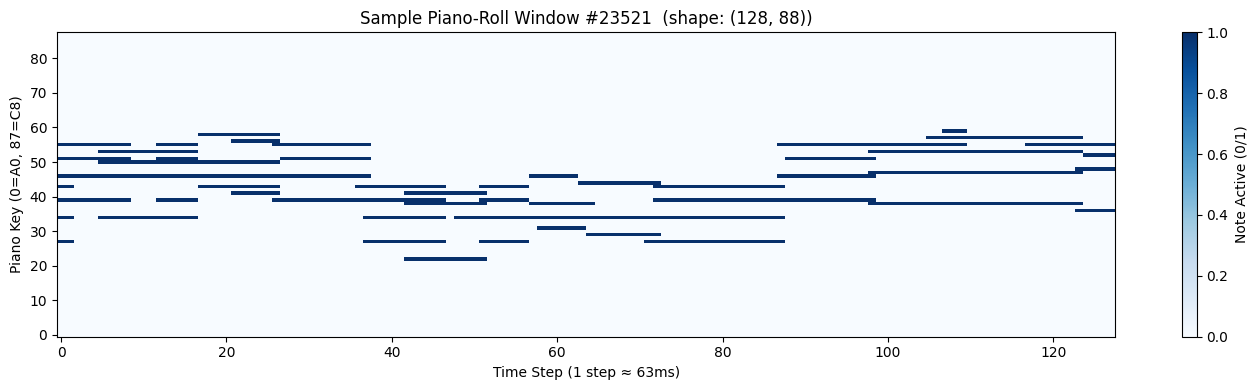

Piano-roll visualization saved!


In [ ]:
#CELL 6: Verify preprocessing - visualize
import matplotlib.pyplot as plt

#Load a saved dataset
data = np.load(f"{PROCESSED_DIR}/piano_roll_train.npy")
print(f"Loaded training data: {data.shape}")
print(f"Sparsity: {1 - data.mean():.2%} of cells are silence")

#Visualize one random window as a piano roll image
idx = np.random.randint(0, len(data))
sample = data[idx]

plt.figure(figsize=(14, 4))
plt.imshow(sample.T, aspect='auto', origin='lower', cmap='Blues', interpolation='nearest')
plt.colorbar(label='Note Active (0/1)')
plt.xlabel('Time Step (1 step ≈ 63ms)')
plt.ylabel('Piano Key (0=A0, 87=C8)')
plt.title(f'Sample Piano-Roll Window #{idx} (shape: {sample.shape})')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/sample_piano_roll.png", dpi=150)
plt.show()
print("Piano-roll visualization saved!")

In [ ]:
#CELL 7: PyTorch Dataset and DataLoader

import torch
from torch.utils.data import Dataset, DataLoader

class PianoRollDataset(Dataset):
    """PyTorch Dataset for binary piano-roll windows.
    Args: npy_path : path to a preprocessed .npy file of shape (N, T, 88)"""
    def __init__(self, npy_path):
        self.data = np.load(npy_path)  #Shape: (N, T, 88)
        print(f"Loaded dataset from {npy_path}: {self.data.shape}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        return torch.tensor(self.data[idx], dtype=torch.float32)


#Create DataLoaders
BATCH_SIZE = 64
train_dataset = PianoRollDataset(f"{PROCESSED_DIR}/piano_roll_train.npy")
val_dataset = PianoRollDataset(f"{PROCESSED_DIR}/piano_roll_validation.npy")
test_dataset  = PianoRollDataset(f"{PROCESSED_DIR}/piano_roll_test.npy")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\nDataLoaders ready:")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Loaded dataset from /content/drive/MyDrive/MusicGenerationCSE425/data/processed/piano_roll_train.npy: (62689, 128, 88)
Loaded dataset from /content/drive/MyDrive/MusicGenerationCSE425/data/processed/piano_roll_validation.npy: (7876, 128, 88)
Loaded dataset from /content/drive/MyDrive/MusicGenerationCSE425/data/processed/piano_roll_test.npy: (7792, 128, 88)

DataLoaders ready:
Train batches: 980
Validation batches: 124
Test batches: 122
